In [4]:
from dolfinx import mesh, fem
from dolfinx.io import XDMFFile
from mpi4py import MPI
import numpy as np
import ufl
from petsc4py import PETSc
import basix
import os
import jax
import jax.numpy as jnp
from jax import jacfwd
from functools import partial
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
jax.config.update("jax_enable_x64", True)

In [5]:
from FE_functions.ElasticModulus import compute_elastic_tangent_jax
from FE_functions.TensorsStr import strain_to_voigt, stress_to_voigt, voigt_to_stress
from FE_functions.RadialReturn import radial_return_jax
from FE_functions.BMatrix import compute_B_matrix
from FE_functions.Assembler import ConsistentTangentAssembler
from FE_functions.GradU import compute_grad_u_at_qp
from FE_functions.Residual import assemble_residual
from FE_functions.HistoryUpd_SS import update_history_and_tangents
from FE_functions.NewtonUpd import Newton_Solver_FullTangent

In [6]:
domain = mesh.create_unit_cube(MPI.COMM_WORLD, nx=1, ny=1, nz=1,
                               cell_type=mesh.CellType.hexahedron)
E, nu, Y0, h = 210000.0, 0.0, 250.0, 1000.0
#E, nu, Y0, h = 210000.0, 0.0, 105000.0, 2100.0
#E, nu, Y0, h = 2000.0, 0.0, 1000.0, 200.0
mu = E / (2*(1 + nu))
clambda = E*nu / ((1 + nu)*(1 - 2*nu))
delta  = 10.0 #Saturation parameter for nonlinear isotropic hardening
#Y_inf  = E / 2 + E / 10
Y_inf = 500.0
Y_init = Y0

print(f"\nMaterial: E={E}, nu={nu}, Y0={Y0}, h={h}")

#Function spaces
vector_el = basix.ufl.element(basix.ElementFamily.P, domain.topology.cell_name(), 1, shape=(3,))
V = fem.functionspace(domain, vector_el)


Material: E=210000.0, nu=0.0, Y0=250.0, h=1000.0


In [7]:
qdeg = 2
basix_cell = basix.CellType.hexahedron
q_el_scalar = basix.ufl.quadrature_element(cell=basix_cell, degree=qdeg, value_shape=())
q_el_tensor = basix.ufl.quadrature_element(cell=basix_cell, degree=qdeg, value_shape=(3, 3))

Q_scalar = fem.functionspace(domain, q_el_scalar)
Q_tensor = fem.functionspace(domain, q_el_tensor)

u = fem.Function(V, name="Displacement")
u_old = fem.Function(V, name="Previous_Displacement")
sigma_q = fem.Function(Q_tensor, name="Stress")
eps_p_q = fem.Function(Q_scalar, name="Plastic_Strain")
Y_q = fem.Function(Q_scalar, name="Yield_Stress")

q_el_vector6 = basix.ufl.quadrature_element(cell=basix_cell, degree=qdeg, value_shape=(6,))
Q_vector6 = fem.functionspace(domain, q_el_vector6)
alpha_q = fem.Function(Q_vector6, name="Backstress")
alpha_q.x.array[:] = 0.0

u.x.array[:] = 0.0
u_old.x.array[:] = 0.0
sigma_q.x.array[:] = 0.0
eps_p_q.x.array[:] = 0.0
Y_q.x.array[:] = Y0

print(f"DOFs: {V.dofmap.index_map.size_global * V.dofmap.index_map_bs}")

DOFs: 24


In [8]:
num_cells = domain.topology.index_map(domain.topology.dim).size_local
qp_points, qp_weights = basix.make_quadrature(basix.CellType.hexahedron, qdeg)
num_qp = qp_points.shape[0]

scalar_element = basix.create_element(basix.ElementFamily.P, basix.CellType.hexahedron, 1,
                                      basix.LagrangeVariant.equispaced)
tab = scalar_element.tabulate(1, qp_points)
num_nodes = tab[0].shape[1]

#Basis function gradients: basis_grad[qp, node, direction]
basis_grad = np.zeros((num_qp, num_nodes, 3))
basis_grad[:, :, 0] = tab[1, :, :, 0]  # dN/dx
basis_grad[:, :, 1] = tab[2, :, :, 0]  # dN/dy
basis_grad[:, :, 2] = tab[3, :, :, 0]  # dN/dz

print(f"Quadrature: {num_cells} cells x {num_qp} points = {num_cells * num_qp} total QPs")
print(f"Basis functions: {num_nodes} nodes")

Quadrature: 1 cells x 8 points = 8 total QPs
Basis functions: 8 nodes


In [9]:
def get_right_face_dofs(domain, V):
    from dolfinx import mesh as msh
    #Locate boundary facets on x=1
    right_facets = msh.locate_entities_boundary(
        domain, domain.topology.dim - 1,
        lambda x: np.isclose(x[0], 1.0)
    )
    #Locate DOFs on those facets
    right_dofs = fem.locate_dofs_topological(V, domain.topology.dim - 1, right_facets)
    return right_dofs

right_face_dofs = get_right_face_dofs(domain, V)
print(f"Right face DOFs: {right_face_dofs}")

Right face DOFs: [1 3 5 7]


In [10]:
def boundary_x0(x):
    return np.isclose(x[0], 0.0)

bc_dofs = fem.locate_dofs_geometrical(V, boundary_x0)
print(f"Fixed DOFs: {len(bc_dofs)}")

Fixed DOFs: 4



************************************************************
STEP 1/10: Load = 10.0%  (total traction = 500.0 MPa)
************************************************************

Newton (cumulative_traction=500.0):
Running linear isotropic hardening return mapping......
    Iter 0: |du|=4.762e-03, rel=1.000e+00
    Iter 1: |du|=2.868e-03, rel=6.023e-01
    Iter 2: |du|=9.645e-05, rel=2.025e-02
    Iter 3: |du|=7.591e-08, rel=1.594e-05
    Iter 4: |du|=4.796e-14, rel=1.007e-11
Converged in 5 iterations!

 Results:
Max plastic strain: 1.787216e-03
Max yield stress: 251.79 MPa
Status: PLASTIC

Displacement:
Max u_x = 3.707186e-03
Max |u_y| = 4.622509e-04
Max |u_z| = 4.622509e-04
sigma_xx after step: 524.66 MPa

************************************************************
STEP 2/10: Load = 20.0%  (total traction = 1000.0 MPa)
************************************************************

Newton (cumulative_traction=1000.0):
    Iter 0: |du|=1.302e-02, rel=1.000e+00
    Iter 1: |du|=9.354e-05

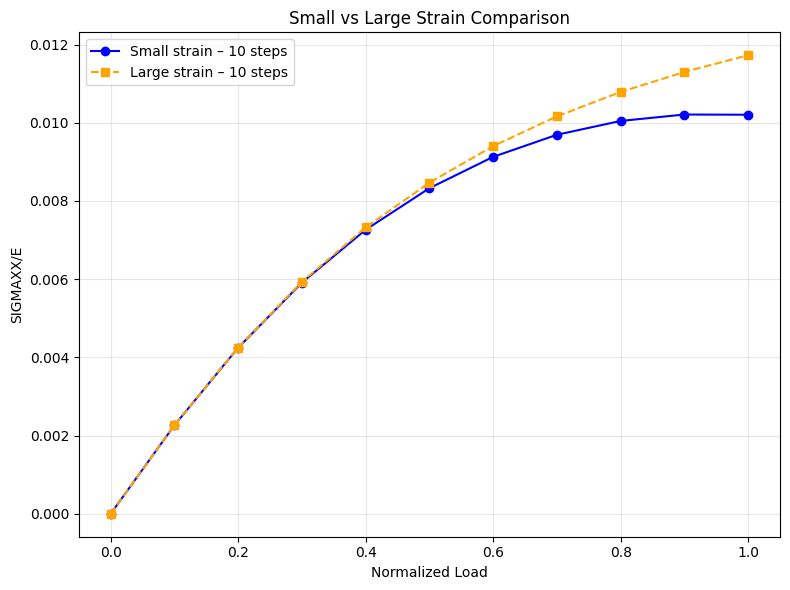

In [11]:
time_history = []
sigmaxx_over_E_history = []

# Reset all state
u.x.array[:] = 0.0
u_old.x.array[:] = 0.0
sigma_q.x.array[:] = 0.0
eps_p_q.x.array[:] = 0.0
Y_q.x.array[:] = Y0
alpha_q.x.array[:] = 0.0
assembler = ConsistentTangentAssembler(V, num_cells, num_qp, basis_grad, qp_weights, E, nu)

P = 5000.0
#num_steps = 100
#delta_traction = P / num_steps
cumulative_traction = 0.0
results = {}

for num_steps in [10]:
    delta_traction = P / num_steps

    # ── Small strain run ───────────────────────────────────────────────
    u.x.array[:] = 0.0;  u_old.x.array[:] = 0.0
    sigma_q.x.array[:] = 0.0;  eps_p_q.x.array[:] = 0.0
    Y_q.x.array[:] = Y0
    alpha_q.x.array[:] = 0.0
    assembler = ConsistentTangentAssembler(V, num_cells, num_qp, basis_grad, qp_weights, E, nu)

    cumulative_traction = 0.0
    times_SS, sigmas_SS = [], []

    for n in range(num_steps):
        cumulative_traction += delta_traction
        time = cumulative_traction / P

        print(f"\n{'*'*60}")
        print(f"STEP {n+1}/{num_steps}: Load = {time:.1%}  (total traction = {cumulative_traction:.1f} MPa)")
        print('*'*60)

        u = Newton_Solver_FullTangent(V, u, u_old, sigma_q, eps_p_q, Y_q,alpha_q, assembler,
                                        30, delta_traction, num_cells, num_qp,
                                        basis_grad, qp_weights, right_face_dofs,
                                        bc_dofs, E, nu, Y0, h,
                                        cumulative_traction=cumulative_traction
                                        , strain = 'small', Y_init= Y_init, Y_inf=Y_inf, 
                                        delta=delta, hardening = 'linear_isotropic')

        sigma_arr = sigma_q.x.array.reshape(num_cells, num_qp, 3, 3)
        sigma_xx  = np.mean([sigma_arr[cell, 5, 0, 0] for cell in range(num_cells)])
        times_SS.append(time)
        sigmas_SS.append(sigma_xx / E)
        max_eps_p = np.max(eps_p_q.x.array)
        max_Y = np.max(Y_q.x.array)

        print(f"\n Results:")
        print(f"Max plastic strain: {max_eps_p:.6e}")
        print(f"Max yield stress: {max_Y:.2f} MPa")
        print(f"Status: {'PLASTIC' if max_eps_p > 1e-10 else 'ELASTIC'}")

        u_array = u.x.array.reshape(-1, 3)
        print(f"\nDisplacement:")
        print(f"Max u_x = {np.max(u_array[:, 0]):.6e}")
        print(f"Max |u_y| = {np.max(np.abs(u_array[:, 1])):.6e}")
        print(f"Max |u_z| = {np.max(np.abs(u_array[:, 2])):.6e}")

        sigma_arr = sigma_q.x.array.reshape(num_cells, num_qp, 3, 3)
        print(f"sigma_xx after step: {sigma_arr[0, 0, 0, 0]:.2f} MPa")
        print("="*60)

    # ── Large strain run ───────────────────────────────────────────────
    u.x.array[:] = 0.0;  u_old.x.array[:] = 0.0
    sigma_q.x.array[:] = 0.0;  eps_p_q.x.array[:] = 0.0
    Y_q.x.array[:] = Y0
    alpha_q.x.array[:] = 0.0
    assembler = ConsistentTangentAssembler(V, num_cells, num_qp, basis_grad, qp_weights, E, nu)

    cumulative_traction = 0.0
    times_LS, sigmas_LS = [], []

    for n in range(num_steps):
        cumulative_traction += delta_traction
        time = cumulative_traction / P #For nomalized load history (load factor)

        print(f"\n{'*'*60}")
        print(f"STEP {n+1}/{num_steps}: Load = {time:.1%}  (total traction = {cumulative_traction:.1f} MPa)")
        print('*'*60)

        u = Newton_Solver_FullTangent(V, u, u_old, sigma_q, eps_p_q, Y_q,alpha_q, assembler,
                                        30, delta_traction, num_cells, num_qp,
                                        basis_grad, qp_weights, right_face_dofs,
                                        bc_dofs, E, nu, Y0, h,
                                        cumulative_traction=cumulative_traction
                                        , strain = 'large1', Y_init= Y_init, Y_inf=Y_inf, 
                                        delta=delta, hardening = 'linear_isotropic')
        sigma_arr = sigma_q.x.array.reshape(num_cells, num_qp, 3, 3)
        sigma_xx  = np.mean([sigma_arr[cell, 5, 0, 0] for cell in range(num_cells)])
        times_LS.append(time)
        sigmas_LS.append(sigma_xx / E)
        max_eps_p = np.max(eps_p_q.x.array)
        max_Y = np.max(Y_q.x.array)

        print(f"\n Results:")
        print(f"Max plastic strain: {max_eps_p:.6e}")
        print(f"Max yield stress: {max_Y:.2f} MPa")
        print(f"Status: {'PLASTIC' if max_eps_p > 1e-10 else 'ELASTIC'}")

        u_array = u.x.array.reshape(-1, 3)
        print(f"\nDisplacement:")
        print(f"Max u_x = {np.max(u_array[:, 0]):.6e}")
        print(f"Max |u_y| = {np.max(np.abs(u_array[:, 1])):.6e}")
        print(f"Max |u_z| = {np.max(np.abs(u_array[:, 2])):.6e}")

        sigma_arr = sigma_q.x.array.reshape(num_cells, num_qp, 3, 3)
        print(f"sigma_xx after step: {sigma_arr[0, 0, 0, 0]:.2f} MPa")
        print("="*60)

    results[num_steps] = (times_SS, sigmas_SS, times_LS, sigmas_LS)

# ── Plot ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['tab:blue', 'tab:orange']

#for (num_steps, (t_SS, s_SS, t_LS, s_LS)), color in zip(results.items(), colors):
for (num_steps, (t_SS, s_SS, t_LS, s_LS)) in results.items():
    t_SS = [0] + list(t_SS) #Making sure the plots start at the origin (0 load, 0 strain)
    s_SS = [0] + list(s_SS)
    t_LS = [0] + list(t_LS)
    s_LS = [0] + list(s_LS)
    ax.plot(t_SS, s_SS, 'o-',  color='blue', label=f'Small strain – {num_steps} steps')
    ax.plot(t_LS, s_LS, 's--', color='orange', label=f'Large strain – {num_steps} steps')

#ax.plot([0, 1], [0, 0.002], 'k-', linewidth=1.5, label='Elastic', alpha=0.5)
ax.set_xlabel('Normalized Load');  ax.set_ylabel('SIGMAXX/E')
ax.set_title('Small vs Large Strain Comparison')
ax.grid(True, alpha=0.3);  ax.legend()
plt.tight_layout();  plt.show()